## 1. Environment Setup

In [ ]:
!pip install -q --upgrade pip
!pip install -q "scikit-learn>=1.3,<1.6" "mapie==0.9.1" xgboost lightgbm catboost shap \
    imbalanced-learn openpyxl matplotlib seaborn statsmodels joblib
print("Packages installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 42.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Packages installed.


In [ ]:
import os
import re
import json
import time
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score, brier_score_loss,
    accuracy_score
)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from scipy import stats

import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import shap
import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# QUICK_MODE = True  -> fast iteration while developing
# QUICK_MODE = False -> settings for the final manuscript run
QUICK_MODE = True

N_CV_SPLITS = 3 if QUICK_MODE else 5
N_BOOTSTRAP = 30 if QUICK_MODE else 150
SHAP_SAMPLE_SIZE = 3000 if QUICK_MODE else 8000  # DataCo's test set is large; sample for SHAP tractability

print("Environment ready. Library versions:")
for lib in [np, pd, xgb, lgb, cb]:
    print(f"  {lib.__name__}: {lib.__version__}")
print(f"QUICK_MODE={QUICK_MODE} | CV splits={N_CV_SPLITS} | Bootstrap reps={N_BOOTSTRAP} | SHAP sample={SHAP_SAMPLE_SIZE}")


Environment ready. Library versions:
  numpy: 2.1.3
  pandas: 2.2.3
  xgboost: 3.4.1
  lightgbm: 4.6.0
  catboost: 1.2.10
QUICK_MODE=True | CV splits=3 | Bootstrap reps=30 | SHAP sample=3000


## 2. Load Dataset
Works both in Google Colab (mounts Drive) and outside Colab. DataCo's CSV export is well documented to
contain non-UTF-8 characters (accented names/cities), so a UTF-8 read commonly fails -- this cell tries
UTF-8 first and automatically falls back to `latin-1`.

In [ ]:
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    PROJECT_DIR = "/content/drive/MyDrive/My Work/Research/AI+ BBA/Supply Chain Disruption/DataCO"
    print("Running in Colab. Drive mounted.")
else:
    PROJECT_DIR = "./supply_chain_project"
    print("Not running in Colab -- using local project directory:", PROJECT_DIR)


Mounted at /content/drive
Running in Colab. Drive mounted.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ---------------- CONFIGURATION (edit only this cell) ----------------
# Edit this to the exact path/filename of your downloaded DataCo CSV in Drive.
DATA_PATH = f"{PROJECT_DIR}/DataCoSupplyChainDataset.csv"

OUTPUT_DIR = f"{PROJECT_DIR}/outputs_dataco"
MODEL_DIR  = f"{OUTPUT_DIR}/models"
FIGURE_DIR = f"{OUTPUT_DIR}/figures"
TABLE_DIR  = f"{OUTPUT_DIR}/tables"
METRIC_DIR = f"{OUTPUT_DIR}/metrics"

for d in [OUTPUT_DIR, MODEL_DIR, FIGURE_DIR, TABLE_DIR, METRIC_DIR]:
    os.makedirs(d, exist_ok=True)

print("Project directories ready under:", PROJECT_DIR)


Project directories ready under: /content/drive/MyDrive/My Work/Research/AI+ BBA/Supply Chain Disruption/DataCO


In [ ]:
assert os.path.exists(DATA_PATH), (
    f"Dataset not found at {DATA_PATH}. Upload the DataCo CSV to this path, "
    f"or edit DATA_PATH in the configuration cell above."
)

try:
    df_raw = pd.read_csv(DATA_PATH, encoding="utf-8")
except UnicodeDecodeError:
    print("UTF-8 read failed (expected for this dataset) -- retrying with latin-1 encoding.")
    df_raw = pd.read_csv(DATA_PATH, encoding="latin-1")

print("Shape:", df_raw.shape)
df_raw.head()


UTF-8 read failed (expected for this dataset) -- retrying with latin-1 encoding.
Shape: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
print("Columns:\n", list(df_raw.columns))
print("\nMissing values per column (top 15):\n", df_raw.isna().sum().sort_values(ascending=False).head(15))
df_raw.describe(include='all').T.head(20)


Columns:
 ['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Type,180519,4,DEBIT,69295,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Days for shipping (real),180519.0,NaN,NaN,NaN,3.497654,1.623722,0.0,2.0,3.0,5.0,6.0
Days for shipment (scheduled),180519.0,NaN,NaN,NaN,2.931847,1.374449,0.0,2.0,4.0,4.0,4.0
Benefit per order,180519.0,NaN,NaN,NaN,21.974989,104.433526,-4274.97998,7.0,31.52,64.800003,911.799988
Sales per customer,180519.0,NaN,NaN,NaN,183.107609,120.04367,7.49,104.379997,163.990005,247.399994,1939.98999
Delivery Status,180519,4,Late delivery,98977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Late_delivery_risk,180519.0,NaN,NaN,NaN,0.548291,0.497664,0.0,0.0,1.0,1.0,1.0
Category Id,180519.0,NaN,NaN,NaN,31.851451,15.640064,2.0,18.0,29.0,45.0,76.0
Category Name,180519,50,Cleats,24551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer City,180519,563,Caguas,66770,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Data Validation & Column Mapping

**Edit this cell if your CSV's column names differ even slightly** (e.g. extra spaces, different
capitalization) -- everything below references these variables, not hardcoded strings elsewhere.

In [ ]:
# ---------------- COLUMN MAPPING (edit only this cell) ----------------
TARGET_COL = "Late_delivery_risk"   # binary: 1 = order shipped later than scheduled (disruption proxy)

# Columns dropped because they are IDENTIFIERS, PII/free text, or EXPLICIT LEAKAGE -- not guesses.
# (Generic ID/PII/date/high-cardinality detection happens automatically in Section 3.4 as a safety net
#  for anything not explicitly listed here or named slightly differently in your export.)
EXPLICIT_LEAKAGE_COLS = [
    "Delivery Status",            # directly restates the label (e.g. "Late delivery" / "Shipping on time")
    "Days for shipping (real)",   # actual shipping duration -- only knowable AFTER the fact
]
EXPLICIT_PII_OR_ID_COLS = [
    "Customer Email", "Customer Password", "Customer Fname", "Customer Lname", "Customer Street",
    "Product Description", "Product Image", "Order Zipcode", "Customer Zipcode",
    "Order Id", "Order Item Id", "Order Item Cardprod Id", "Product Card Id",
    "Order Customer Id", "Customer Id",
]

df = df_raw.copy()

missing_required = [c for c in [TARGET_COL] if c not in df.columns]
assert not missing_required, (
    f"TARGET_COL not found in dataset: {missing_required}. "
    f"Check df_raw.columns above and update TARGET_COL / the drop lists to match your file exactly."
)

DROP_COLS = [c for c in (EXPLICIT_LEAKAGE_COLS + EXPLICIT_PII_OR_ID_COLS) if c in df.columns]
missing_expected = [c for c in (EXPLICIT_LEAKAGE_COLS + EXPLICIT_PII_OR_ID_COLS) if c not in df.columns]
if missing_expected:
    print("NOTE: these expected columns were not found (fine if your export genuinely lacks them, but "
          "double-check for a naming mismatch):", missing_expected)

df = df.drop(columns=DROP_COLS)
print(f"Dropped {len(DROP_COLS)} explicit leakage/PII/ID columns:", DROP_COLS)

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
assert df[TARGET_COL].dropna().isin([0, 1]).all(), "TARGET_COL is not binary 0/1 -- inspect its values."
df = df.dropna(subset=[TARGET_COL])
df[TARGET_COL] = df[TARGET_COL].astype(int)

print("\nTarget distribution:")
print(df[TARGET_COL].value_counts(normalize=True).rename("proportion"))


Dropped 17 explicit leakage/PII/ID columns: ['Delivery Status', 'Days for shipping (real)', 'Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname', 'Customer Street', 'Product Description', 'Product Image', 'Order Zipcode', 'Customer Zipcode', 'Order Id', 'Order Item Id', 'Order Item Cardprod Id', 'Product Card Id', 'Order Customer Id', 'Customer Id']

Target distribution:
Late_delivery_risk
1    0.548291
0    0.451709
Name: proportion, dtype: float64


## 3.4 Feature Hygiene: Automatic ID / Date / High-Cardinality Detection  *(new)*
A 53-column, order-level e-commerce dataset like this one has several columns that are neither leakage
nor useful predictors: order/customer/product identifiers, and free-text/very-high-cardinality fields
that would either blow up one-hot encoding or contribute no generalizable signal. This cell detects and
drops them **automatically by pattern and cardinality**, as a safety net beyond the explicit list in
Section 3, and prints exactly what it removed and why (for your Data Validation subsection).

In [ ]:
# ---------------- FEATURE HYGIENE CONFIGURATION ----------------
ID_NAME_PATTERN = re.compile(r'(^|[ _])(id)([ _]|$)', re.IGNORECASE)
PII_NAME_PATTERN = re.compile(r'email|password|street|image|description', re.IGNORECASE)
HIGH_CARDINALITY_THRESHOLD = 50   # object columns with more unique values than this are dropped
ID_UNIQUENESS_RATIO = 0.5         # object/int columns with unique-value ratio above this are ID-like

hygiene_dropped = {"id_like": [], "pii_like": [], "datetime_like": [], "high_cardinality": []}

feature_cols_pre = [c for c in df.columns if c != TARGET_COL]

for c in list(feature_cols_pre):
    if c not in df.columns:
        continue
    name_is_id = bool(ID_NAME_PATTERN.search(c))
    name_is_pii = bool(PII_NAME_PATTERN.search(c))
    uniqueness_ratio = df[c].nunique(dropna=True) / max(len(df), 1)

    if name_is_pii:
        hygiene_dropped["pii_like"].append(c)
        df = df.drop(columns=[c])
        continue
    if name_is_id and uniqueness_ratio > ID_UNIQUENESS_RATIO:
        hygiene_dropped["id_like"].append(c)
        df = df.drop(columns=[c])
        continue

print("Dropped as PII/free-text:", hygiene_dropped["pii_like"])
print("Dropped as ID-like (name pattern + high uniqueness):", hygiene_dropped["id_like"])


Dropped as PII/free-text: []
Dropped as ID-like (name pattern + high uniqueness): []


### 3.4-extra Constant and exact-duplicate columns  *(new)*
Two more automatic, dataset-agnostic checks: a column with **zero variance** (every row identical)
carries no information and should be dropped; a column that is an **exact duplicate** of another column
(e.g. two differently named fields that always hold the same value) inflates multicollinearity and
double-counts the same signal without adding anything. Both are detected and dropped generically here,
which caught real cases in the DataCo file (an all-constant `Product Status` field, and two duplicate
column pairs) without needing to hardcode their names.

In [ ]:
remaining_feature_cols = [c for c in df.columns if c != TARGET_COL]

constant_cols = [c for c in remaining_feature_cols if df[c].nunique(dropna=False) <= 1]
df = df.drop(columns=constant_cols)
hygiene_dropped["constant"] = constant_cols
print("Dropped constant (zero-variance) columns:", constant_cols)

remaining_feature_cols = [c for c in df.columns if c != TARGET_COL]
seen_hashes = {}
duplicate_cols = []
for c in remaining_feature_cols:
    col_hash = pd.util.hash_pandas_object(df[c], index=False).sum()
    if col_hash in seen_hashes and df[c].equals(df[seen_hashes[col_hash]]):
        duplicate_cols.append(c)
    else:
        seen_hashes[col_hash] = c

df = df.drop(columns=duplicate_cols)
hygiene_dropped["exact_duplicate"] = duplicate_cols
print("Dropped exact-duplicate columns (identical to another retained column):", duplicate_cols)


Dropped constant (zero-variance) columns: ['Product Status']
Dropped exact-duplicate columns (identical to another retained column): ['Order Item Total', 'Order Profit Per Order', 'Product Category Id', 'Product Price']


### 3.4a Datetime detection
Any remaining object column that parses as a date for the large majority of its (non-null) values is
treated as a raw datetime string. **Order-date-like columns are engineered into safe features in 3.4b
before being dropped here; anything shipping-date-like is dropped outright** (only knowable after the
order has actually shipped, i.e. after the outcome).

In [ ]:
remaining_object_cols = df.select_dtypes(include=["object"]).columns.tolist()
remaining_object_cols = [c for c in remaining_object_cols if c != TARGET_COL]

datetime_like_cols = []
for c in remaining_object_cols:
    sample = df[c].dropna().sample(min(500, df[c].notna().sum()), random_state=RANDOM_STATE) if df[c].notna().sum() > 0 else df[c]
    if len(sample) == 0:
        continue
    parsed = pd.to_datetime(sample, errors="coerce", format="mixed")
    if parsed.notna().mean() > 0.9:
        datetime_like_cols.append(c)

print("Detected datetime-like columns:", datetime_like_cols)

ORDER_DATE_COL = next((c for c in datetime_like_cols if re.search(r'order.*date', c, re.IGNORECASE)), None)
SHIP_DATE_COLS = [c for c in datetime_like_cols if re.search(r'ship', c, re.IGNORECASE) and c != ORDER_DATE_COL]

print("Order-date column (will be feature-engineered, then dropped raw):", ORDER_DATE_COL)
print("Shipping-date-like column(s) (dropped outright -- post-outcome leakage risk):", SHIP_DATE_COLS)


Detected datetime-like columns: ['order date (DateOrders)', 'shipping date (DateOrders)']
Order-date column (will be feature-engineered, then dropped raw): order date (DateOrders)
Shipping-date-like column(s) (dropped outright -- post-outcome leakage risk): ['shipping date (DateOrders)']


### 3.4b Safe, order-time-only date feature engineering
Extracts day-of-week, month, quarter, and weekend indicators from the **order date only** -- these are
genuinely known at the moment the order is placed, before any disruption/late-delivery outcome exists, so
they carry legitimate signal (e.g. seasonal or weekday demand/capacity effects) without leaking the
outcome.

In [ ]:
if ORDER_DATE_COL is not None:
    parsed_order_date = pd.to_datetime(df[ORDER_DATE_COL], errors="coerce", format="mixed")
    df["order_day_of_week"] = parsed_order_date.dt.dayofweek
    df["order_month"] = parsed_order_date.dt.month
    df["order_quarter"] = parsed_order_date.dt.quarter
    df["order_is_weekend"] = parsed_order_date.dt.dayofweek.isin([5, 6]).astype(int)
    print("Engineered 4 order-time-only date features:",
          ["order_day_of_week", "order_month", "order_quarter", "order_is_weekend"])
else:
    print("No order-date column detected -- skipping date feature engineering.")

cols_to_drop_dates = [c for c in datetime_like_cols if c in df.columns]
df = df.drop(columns=cols_to_drop_dates)
hygiene_dropped["datetime_like"] = cols_to_drop_dates
print("Dropped raw datetime string columns:", cols_to_drop_dates)


Engineered 4 order-time-only date features: ['order_day_of_week', 'order_month', 'order_quarter', 'order_is_weekend']
Dropped raw datetime string columns: ['order date (DateOrders)', 'shipping date (DateOrders)']


### 3.4c High-cardinality categorical auto-drop
One-hot encoding a categorical column with hundreds/thousands of unique values (e.g. product name, city)
would explode the feature space and add noise rather than signal at this sample size. These are dropped
and reported; a natural extension for future work is target/frequency encoding instead of dropping them
outright.

In [ ]:
remaining_object_cols = [c for c in df.select_dtypes(include=["object"]).columns if c != TARGET_COL]
high_card_cols = [c for c in remaining_object_cols if df[c].nunique(dropna=True) > HIGH_CARDINALITY_THRESHOLD]

df = df.drop(columns=high_card_cols)
hygiene_dropped["high_cardinality"] = high_card_cols
print(f"Dropped {len(high_card_cols)} high-cardinality categorical columns (> {HIGH_CARDINALITY_THRESHOLD} unique values):")
print(high_card_cols)

with open(f"{METRIC_DIR}/feature_hygiene_report.json", "w") as f:
    json.dump(hygiene_dropped, f, indent=2)

FEATURE_COLS = [c for c in df.columns if c != TARGET_COL]
NUMERIC_COLS = df[FEATURE_COLS].select_dtypes(include=[np.number]).columns.tolist()
CATEGORICAL_COLS = [c for c in FEATURE_COLS if c not in NUMERIC_COLS]

print(f"\nAfter hygiene: {len(FEATURE_COLS)} features retained "
      f"({len(NUMERIC_COLS)} numeric, {len(CATEGORICAL_COLS)} categorical).")
print("Numeric:", NUMERIC_COLS)
print("Categorical:", CATEGORICAL_COLS)


Dropped 5 high-cardinality categorical columns (> 50 unique values):
['Customer City', 'Order City', 'Order Country', 'Order State', 'Product Name']

After hygiene: 27 features retained (17 numeric, 10 categorical).
Numeric: ['Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Category Id', 'Department Id', 'Latitude', 'Longitude', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'order_day_of_week', 'order_month', 'order_quarter', 'order_is_weekend']
Categorical: ['Type', 'Category Name', 'Customer Country', 'Customer Segment', 'Customer State', 'Department Name', 'Market', 'Order Region', 'Order Status', 'Shipping Mode']


In [ ]:
# Data-validation report
validation_report = {
    "n_rows": int(df.shape[0]),
    "n_features": int(len(FEATURE_COLS)),
    "n_numeric": int(len(NUMERIC_COLS)),
    "n_categorical": int(len(CATEGORICAL_COLS)),
    "missing_pct": df[FEATURE_COLS].isna().mean().mul(100).round(2).to_dict(),
    "target_positive_rate": float(df[TARGET_COL].mean()),
    "explicit_leakage_dropped": [c for c in EXPLICIT_LEAKAGE_COLS if c in DROP_COLS],
    "explicit_pii_id_dropped": [c for c in EXPLICIT_PII_OR_ID_COLS if c in DROP_COLS],
    "hygiene_dropped": hygiene_dropped,
}
with open(f"{METRIC_DIR}/data_validation_report.json", "w") as f:
    json.dump(validation_report, f, indent=2)
print(json.dumps(validation_report, indent=2))


{
  "n_rows": 180519,
  "n_features": 27,
  "n_numeric": 17,
  "n_categorical": 10,
  "missing_pct": {
    "Type": 0.0,
    "Days for shipment (scheduled)": 0.0,
    "Benefit per order": 0.0,
    "Sales per customer": 0.0,
    "Category Id": 0.0,
    "Category Name": 0.0,
    "Customer Country": 0.0,
    "Customer Segment": 0.0,
    "Customer State": 0.0,
    "Department Id": 0.0,
    "Department Name": 0.0,
    "Latitude": 0.0,
    "Longitude": 0.0,
    "Market": 0.0,
    "Order Item Discount": 0.0,
    "Order Item Discount Rate": 0.0,
    "Order Item Product Price": 0.0,
    "Order Item Profit Ratio": 0.0,
    "Order Item Quantity": 0.0,
    "Sales": 0.0,
    "Order Region": 0.0,
    "Order Status": 0.0,
    "Shipping Mode": 0.0,
    "order_day_of_week": 0.0,
    "order_month": 0.0,
    "order_quarter": 0.0,
    "order_is_weekend": 0.0
  },
  "target_positive_rate": 0.5482913155955883,
  "explicit_leakage_dropped": [
    "Delivery Status",
    "Days for shipping (real)"
  ],
  "expli

## 3.5 Leakage & Multicollinearity Audit
Same automatic, data-driven audit used on the previous dataset: univariate ROC-AUC (numeric) / Cramer's V
(categorical) against the target, thresholded and auto-dropped, plus a VIF multicollinearity report. This
is what would catch anything the explicit list in Section 3 missed (e.g. a slightly differently named
column that still leaks the label).

In [ ]:
LEAKAGE_AUC_THRESHOLD  = 0.97
LEAKAGE_CORR_THRESHOLD = 0.90
LEAKAGE_WHITELIST = []

def _cramers_v(confusion_matrix):
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    r, k = confusion_matrix.shape
    denom = min(k - 1, r - 1)
    if denom <= 0 or n == 0:
        return 0.0
    return float(np.sqrt((chi2 / n) / denom))

leakage_scores = {}

for c in NUMERIC_COLS:
    col = df[c]
    if col.nunique(dropna=True) < 2:
        continue
    try:
        filled = col.fillna(col.median())
        auc = roc_auc_score(df[TARGET_COL], filled)
        leakage_scores[c] = max(auc, 1 - auc)
    except Exception:
        pass

for c in CATEGORICAL_COLS:
    try:
        ct = pd.crosstab(df[c].fillna("missing"), df[TARGET_COL])
        leakage_scores[c] = _cramers_v(ct.values)
    except Exception:
        pass

leakage_series = pd.Series(leakage_scores).sort_values(ascending=False)
print("Univariate association with target (AUC for numeric / Cramer's V for categorical):")
print(leakage_series.round(4))

LEAK_SUSPECT_COLS = [c for c in NUMERIC_COLS
                      if leakage_scores.get(c, 0) >= LEAKAGE_AUC_THRESHOLD and c not in LEAKAGE_WHITELIST]
LEAK_SUSPECT_COLS += [c for c in CATEGORICAL_COLS
                       if leakage_scores.get(c, 0) >= LEAKAGE_CORR_THRESHOLD and c not in LEAKAGE_WHITELIST]

print("\nColumns flagged as target leakage:", LEAK_SUSPECT_COLS if LEAK_SUSPECT_COLS else "none")

leakage_report = {
    "auc_threshold": LEAKAGE_AUC_THRESHOLD,
    "cramers_v_threshold": LEAKAGE_CORR_THRESHOLD,
    "scores": {k: float(v) for k, v in leakage_scores.items()},
    "dropped_columns": LEAK_SUSPECT_COLS,
}
with open(f"{METRIC_DIR}/leakage_audit_report.json", "w") as f:
    json.dump(leakage_report, f, indent=2)


Univariate association with target (AUC for numeric / Cramer's V for categorical):
Days for shipment (scheduled)    0.6984
Benefit per order                0.5017
Sales                            0.5016
Sales per customer               0.5015
order_month                      0.5015
Order Item Product Price         0.5015
Longitude                        0.5014
Order Item Discount              0.5012
order_day_of_week                0.5006
order_quarter                    0.5006
Order Item Profit Ratio          0.5006
Category Id                      0.5005
order_is_weekend                 0.5004
Department Id                    0.5004
Order Item Quantity              0.5003
Order Item Discount Rate         0.5002
Latitude                         0.5002
Shipping Mode                    0.4571
Order Status                     0.2336
Type                             0.0782
Customer State                   0.0237
Order Region                     0.0204
Category Name                    0.01

In [ ]:
# Multicollinearity audit (VIF) -- report only, no auto-drop (trees are robust to it)
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_pre_leakage_removal = [c for c in NUMERIC_COLS if c not in LEAK_SUSPECT_COLS]
vif_rows = []
if len(numeric_pre_leakage_removal) > 1:
    X_vif = df[numeric_pre_leakage_removal].fillna(df[numeric_pre_leakage_removal].median())
    for i, col in enumerate(numeric_pre_leakage_removal):
        try:
            vif_val = variance_inflation_factor(X_vif.values, i)
        except Exception:
            vif_val = np.nan
        vif_rows.append({"feature": col, "VIF": vif_val})

vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
vif_df.to_csv(f"{TABLE_DIR}/table00b_multicollinearity_vif.csv", index=False)
print("Variance Inflation Factors (VIF > 10 suggests notable multicollinearity):")
print(vif_df.round(2))
HIGH_VIF_COLS = vif_df.loc[vif_df["VIF"] > 10, "feature"].tolist()


Variance Inflation Factors (VIF > 10 suggests notable multicollinearity):
                          feature           VIF
12                          Sales  7.623096e+09
2              Sales per customer  6.278671e+09
7             Order Item Discount  2.070730e+08
9        Order Item Product Price  2.141000e+01
15                  order_quarter  1.727000e+01
14                    order_month  1.724000e+01
11            Order Item Quantity  7.130000e+00
3                     Category Id  5.030000e+00
4                   Department Id  4.880000e+00
8        Order Item Discount Rate  3.380000e+00
1               Benefit per order  3.300000e+00
10        Order Item Profit Ratio  3.240000e+00
16               order_is_weekend  2.670000e+00
13              order_day_of_week  2.670000e+00
5                        Latitude  1.380000e+00
6                       Longitude  1.380000e+00
0   Days for shipment (scheduled)  1.000000e+00


## 3.6 Leakage Ablation  *(new -- quantifies the audit's impact, for your manuscript)*
Trains a quick, single Random Forest **with** the flagged leakage columns still included vs. **without**
them (everything else identical), on an 80/20 split. Reporting this side by side turns "we removed some
columns because we suspected leakage" into a quantified, citable result: exactly how much apparent
performance the leakage was buying, and what genuinely predictive performance looks like once it's gone.
This table is exactly the kind of evidence a Q1 reviewer wants to see in a Data Validation subsection.

In [ ]:
def quick_eval(feature_cols, numeric_cols, categorical_cols, label):
    Xa = df[feature_cols]
    ya = df[TARGET_COL]
    Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(Xa, ya, test_size=0.2, stratify=ya, random_state=RANDOM_STATE)

    prep = ColumnTransformer(transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_cols),
    ])
    pipe = Pipeline([("prep", prep), ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))])
    pipe.fit(Xa_tr, ya_tr)
    proba = pipe.predict_proba(Xa_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "label": label, "n_features": len(feature_cols),
        "Accuracy": accuracy_score(ya_te, pred), "F1": f1_score(ya_te, pred),
        "ROC_AUC": roc_auc_score(ya_te, proba), "PR_AUC": average_precision_score(ya_te, proba),
    }

results_with_leak = quick_eval(FEATURE_COLS, NUMERIC_COLS, CATEGORICAL_COLS, "WITH flagged leakage columns")

clean_features = [c for c in FEATURE_COLS if c not in LEAK_SUSPECT_COLS]
clean_numeric = [c for c in NUMERIC_COLS if c not in LEAK_SUSPECT_COLS]
clean_categorical = [c for c in CATEGORICAL_COLS if c not in LEAK_SUSPECT_COLS]
results_without_leak = quick_eval(clean_features, clean_numeric, clean_categorical, "WITHOUT flagged leakage columns")

ablation_df = pd.DataFrame([results_with_leak, results_without_leak]).set_index("label").round(4)
ablation_df.to_csv(f"{TABLE_DIR}/table00c_leakage_ablation.csv")
print(ablation_df)

if not LEAK_SUSPECT_COLS:
    print("\nNo columns were flagged in Section 3.5, so both rows above should be identical -- "
          "this is itself a useful sanity check that the audit is behaving correctly.")

# Apply the drop for the rest of the notebook
df = df.drop(columns=LEAK_SUSPECT_COLS)
FEATURE_COLS, NUMERIC_COLS, CATEGORICAL_COLS = clean_features, clean_numeric, clean_categorical
print(f"\nProceeding with {len(FEATURE_COLS)} leakage-audited features "
      f"({len(NUMERIC_COLS)} numeric, {len(CATEGORICAL_COLS)} categorical).")


                                 n_features  Accuracy      F1  ROC_AUC  PR_AUC
label                                                                         
WITH flagged leakage columns             27    0.7589  0.7571   0.8538  0.8905
WITHOUT flagged leakage columns          27    0.7589  0.7571   0.8538  0.8905

No columns were flagged in Section 3.5, so both rows above should be identical -- this is itself a useful sanity check that the audit is behaving correctly.

Proceeding with 27 leakage-audited features (17 numeric, 10 categorical).


## 4. Exploratory Data Analysis (EDA)

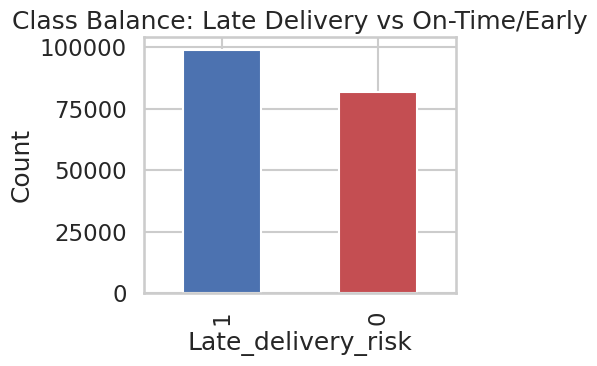

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
df[TARGET_COL].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_title("Class Balance: Late Delivery vs On-Time/Early")
ax.set_xlabel(TARGET_COL); ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/fig01_class_balance.png", dpi=300)
plt.show()


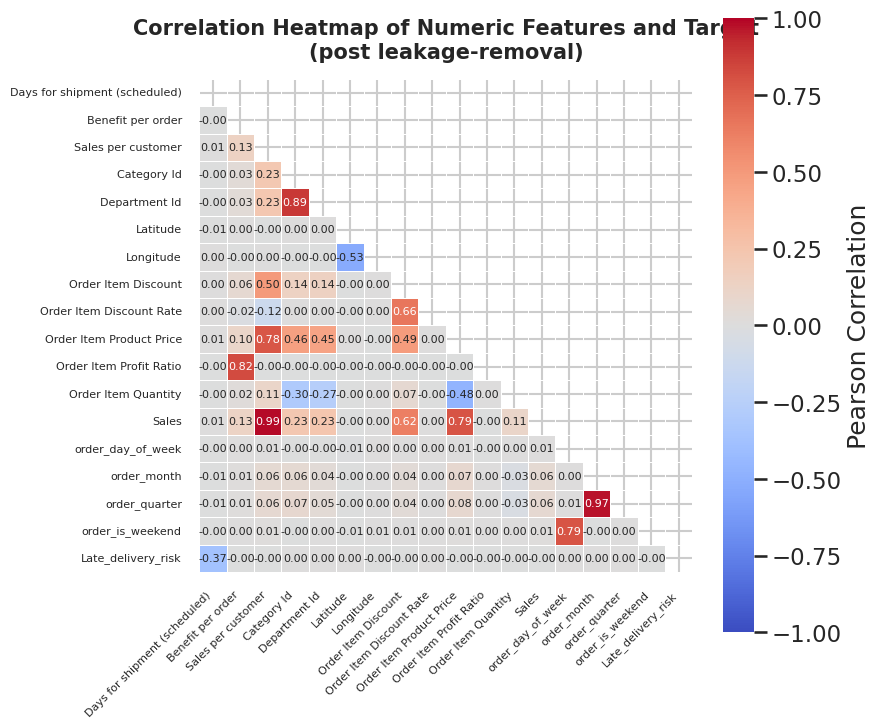

Highest |correlation| of any remaining feature with the target: 0.369


In [ ]:
if len(NUMERIC_COLS) > 1:
    corr = df[NUMERIC_COLS + [TARGET_COL]].corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    n = len(corr)
    fig_size = max(8, 0.5 * n)

    plt.figure(figsize=(fig_size, fig_size))
    ax = sns.heatmap(
        corr, mask=mask, cmap="coolwarm", vmin=-1, vmax=1, center=0,
        annot=n <= 25, fmt=".2f", square=True, linewidths=0.5, linecolor="white",
        cbar_kws={"shrink": 0.8, "label": "Pearson Correlation"}, annot_kws={"size": 8},
    )
    ax.set_title("Correlation Heatmap of Numeric Features and Target\n(post leakage-removal)",
                 fontsize=15, fontweight="bold", pad=15)
    ax.set_xlabel(""); ax.set_ylabel("")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(f"{FIGURE_DIR}/fig02_correlation_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    max_abs_corr_with_target = corr[TARGET_COL].drop(TARGET_COL).abs().max()
    print(f"Highest |correlation| of any remaining feature with the target: {max_abs_corr_with_target:.3f}")


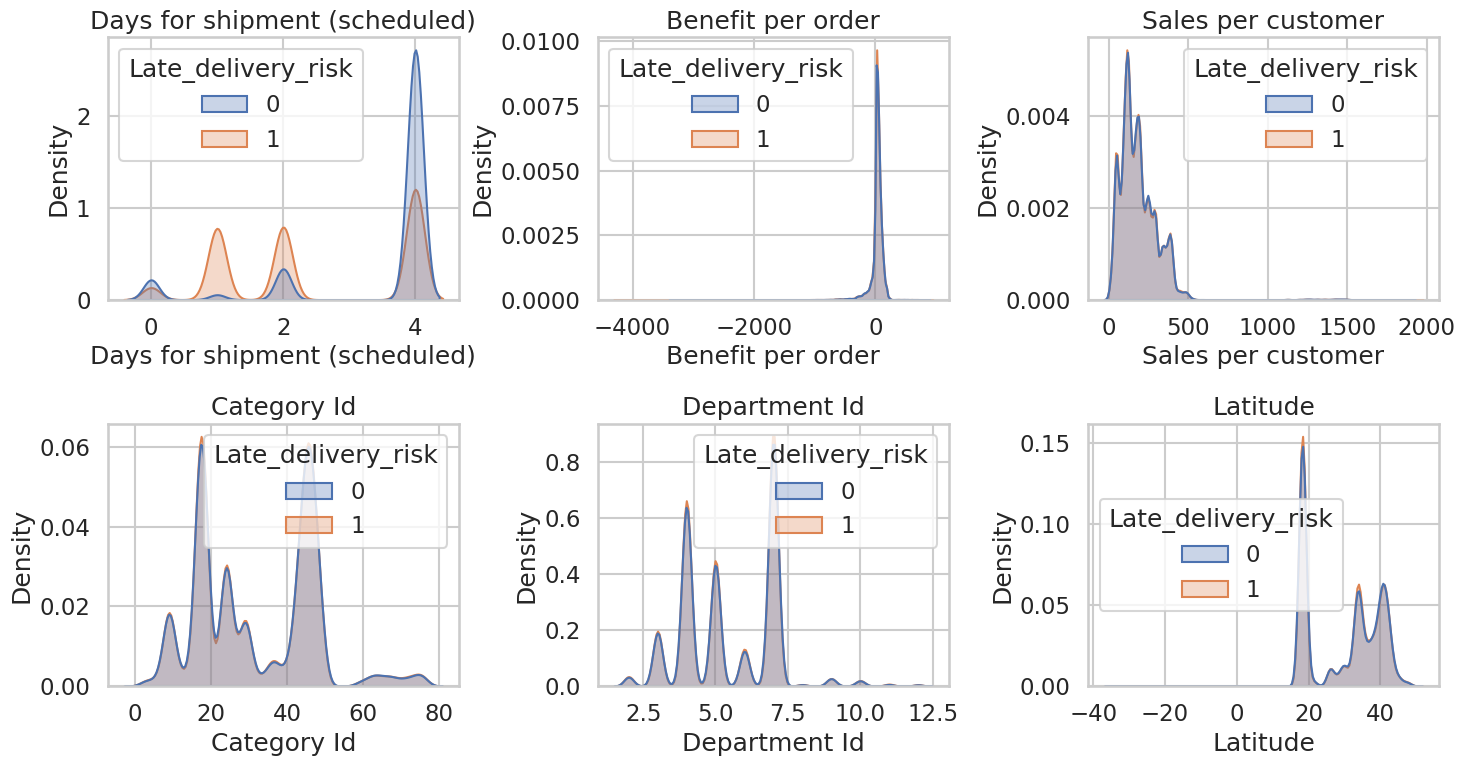

In [ ]:
n_show = min(6, len(NUMERIC_COLS))
if n_show > 0:
    fig, axes = plt.subplots(2, (n_show + 1) // 2, figsize=(5 * ((n_show + 1) // 2), 8))
    axes = np.array(axes).flatten()
    for i, col in enumerate(NUMERIC_COLS[:n_show]):
        sns.kdeplot(data=df, x=col, hue=TARGET_COL, common_norm=False, ax=axes[i], fill=True, alpha=0.3)
        axes[i].set_title(col)
    for j in range(n_show, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.savefig(f"{FIGURE_DIR}/fig03_feature_distributions.png", dpi=300)
    plt.show()


## 5. Stratified Train / Calibration / Test Split
60% train / 20% calibration / 20% test. With ~180k rows, even the 20% calibration/test splits are large
(~36k rows each), which gives stable calibration and conformal-coverage estimates.

In [ ]:
# Keep the market/region column aside (if present) for the subgroup coverage check in Section 9c,
# even though it also participates as a normal categorical feature in modeling.
REGION_COL_CANDIDATES = [c for c in CATEGORICAL_COLS if re.search(r'market|region', c, re.IGNORECASE)]
SUBGROUP_COL = REGION_COL_CANDIDATES[0] if REGION_COL_CANDIDATES else None
print("Subgroup column for coverage analysis:", SUBGROUP_COL)

X = df[FEATURE_COLS]
y = df[TARGET_COL].astype(int)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE
)
X_calib, X_test, y_calib, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} | Calibration: {X_calib.shape[0]} | Test: {X_test.shape[0]}")
print("Positive rate  -> train: %.3f | calib: %.3f | test: %.3f" %
      (y_train.mean(), y_calib.mean(), y_test.mean()))


Subgroup column for coverage analysis: Market
Train: 108311 | Calibration: 36104 | Test: 36104
Positive rate  -> train: 0.548 | calib: 0.548 | test: 0.548


## 6. Preprocessing Pipeline

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, NUMERIC_COLS),
    ("cat", categorical_transformer, CATEGORICAL_COLS),
])
print("Preprocessing pipeline defined.")


Preprocessing pipeline defined.


## 7. Model Training: XGBoost, LightGBM, CatBoost, Random Forest -- vs. Baselines
**Baselines are included in the same comparison table** (majority-class `DummyClassifier` and
`LogisticRegression`) -- reviewers expect to see the proposed ensemble models clearly beat a real floor,
not just be compared against each other.

In [ ]:
models = {
    "Baseline_MajorityClass": DummyClassifier(strategy="most_frequent"),
    "Baseline_LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=400, max_depth=-1, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    ),
    "CatBoost": cb.CatBoostClassifier(
        iterations=400, depth=6, learning_rate=0.05,
        random_state=RANDOM_STATE, verbose=False,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=500, max_depth=None,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
}

pipelines = {name: Pipeline(steps=[("prep", preprocessor), ("clf", clf)]) for name, clf in models.items()}

scoring = {
    "accuracy": "accuracy", "precision": "precision", "recall": "recall",
    "f1": "f1", "pr_auc": "average_precision", "roc_auc": "roc_auc",
}
cv = StratifiedKFold(n_splits=N_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

cv_results, fold_scores = {}, {}
for name, pipe in pipelines.items():
    t0 = time.time()
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    cv_results[name] = {
        "Accuracy_mean": res["test_accuracy"].mean(), "Accuracy_std": res["test_accuracy"].std(),
        "Precision_mean": res["test_precision"].mean(), "Precision_std": res["test_precision"].std(),
        "Recall_mean": res["test_recall"].mean(), "Recall_std": res["test_recall"].std(),
        "F1_mean": res["test_f1"].mean(), "F1_std": res["test_f1"].std(),
        "PR_AUC_mean": res["test_pr_auc"].mean(), "PR_AUC_std": res["test_pr_auc"].std(),
        "ROC_AUC_mean": res["test_roc_auc"].mean(), "ROC_AUC_std": res["test_roc_auc"].std(),
        "fit_time_s": round(time.time() - t0, 1),
    }
    fold_scores[name] = res["test_f1"]
    print(f"{name}: done in {time.time() - t0:.1f}s | F1={res['test_f1'].mean():.4f}, "
          f"ROC_AUC={res['test_roc_auc'].mean():.4f}, PR_AUC={res['test_pr_auc'].mean():.4f}")

cv_table = pd.DataFrame(cv_results).T.round(4)
cv_table.to_csv(f"{TABLE_DIR}/table01_cv_model_comparison.csv")
cv_table


Baseline_MajorityClass: done in 4.2s | F1=0.7083, ROC_AUC=0.5000, PR_AUC=0.5483
Baseline_LogisticRegression: done in 5.7s | F1=0.6757, ROC_AUC=0.7693, PR_AUC=0.8367
XGBoost: done in 16.1s | F1=0.6883, ROC_AUC=0.7895, PR_AUC=0.8489
LightGBM: done in 30.7s | F1=0.6899, ROC_AUC=0.7966, PR_AUC=0.8536
CatBoost: done in 30.0s | F1=0.6843, ROC_AUC=0.7891, PR_AUC=0.8487
RandomForest: done in 2204.6s | F1=0.7225, ROC_AUC=0.8176, PR_AUC=0.8670


,Accuracy_mean,Accuracy_std,Precision_mean,Precision_std,Recall_mean,Recall_std,F1_mean,F1_std,PR_AUC_mean,PR_AUC_std,ROC_AUC_mean,ROC_AUC_std,fit_time_s
Baseline_MajorityClass,0.5483,0.0000,0.5483,0.0000,1.0000,0.0000,0.7083,0.0000,0.5483,0.0000,0.5000,0.0000,4.2
Baseline_LogisticRegression,0.7098,0.0009,0.8721,0.0019,0.5515,0.0028,0.6757,0.0017,0.8367,0.0004,0.7693,0.0005,5.7
XGBoost,0.7132,0.0014,0.8518,0.0022,0.5774,0.0023,0.6883,0.0018,0.8489,0.0005,0.7895,0.0003,16.1
LightGBM,0.7152,0.0013,0.8560,0.0015,0.5777,0.0040,0.6899,0.0025,0.8536,0.0009,0.7966,0.0011,30.7
CatBoost,0.7141,0.0008,0.8672,0.0024,0.5651,0.0016,0.6843,0.0009,0.8487,0.0007,0.7891,0.0014,30.0
RandomForest,0.7313,0.0004,0.8331,0.0017,0.6378,0.0022,0.7225,0.0009,0.8670,0.0005,0.8176,0.0008,2204.6


In [ ]:
# Statistical significance between the two best NON-baseline models
non_baseline = [n for n in cv_table.index if not n.startswith("Baseline_")]
ranked = cv_table.loc[non_baseline, "F1_mean"].sort_values(ascending=False)
best_two = ranked.index[:2].tolist()
try:
    stat, p_value = stats.wilcoxon(fold_scores[best_two[0]], fold_scores[best_two[1]])
except ValueError as e:
    stat, p_value = np.nan, np.nan
    print(f"Wilcoxon test could not be computed ({e}); use N_CV_SPLITS >= 5 for the final run.")

sig_report = {
    "compared_models": best_two,
    "wilcoxon_stat": float(stat) if stat == stat else None,
    "p_value": float(p_value) if p_value == p_value else None,
    "significant_at_0.05": bool(p_value < 0.05) if p_value == p_value else None,
}
with open(f"{METRIC_DIR}/significance_test.json", "w") as f:
    json.dump(sig_report, f, indent=2)
print(json.dumps(sig_report, indent=2))


{
  "compared_models": [
    "RandomForest",
    "LightGBM"
  ],
  "wilcoxon_stat": 0.0,
  "p_value": 0.25,
  "significant_at_0.05": false
}


In [ ]:
# Best model = best F1 among the real models (baselines excluded from selection)
BEST_MODEL_NAME = ranked.index[0]
print("Best model selected for the downstream pipeline:", BEST_MODEL_NAME)

best_pipeline = pipelines[BEST_MODEL_NAME]
best_pipeline.fit(X_train, y_train)
joblib.dump(best_pipeline, f"{MODEL_DIR}/best_model_{BEST_MODEL_NAME}.joblib")
print("Saved:", f"{MODEL_DIR}/best_model_{BEST_MODEL_NAME}.joblib")


Best model selected for the downstream pipeline: RandomForest
Saved: /content/drive/MyDrive/My Work/Research/AI+ BBA/Supply Chain Disruption/DataCO/outputs_dataco/models/best_model_RandomForest.joblib


In [ ]:
proba_test_raw = best_pipeline.predict_proba(X_test)[:, 1]
pred_test_raw = (proba_test_raw >= 0.5).astype(int)

test_metrics_raw = {
    "F1": f1_score(y_test, pred_test_raw),
    "PR_AUC": average_precision_score(y_test, proba_test_raw),
    "ROC_AUC": roc_auc_score(y_test, proba_test_raw),
    "Brier": brier_score_loss(y_test, proba_test_raw),
}
print("Uncalibrated test metrics:", json.dumps(test_metrics_raw, indent=2))


Uncalibrated test metrics: {
  "F1": 0.740266364409181,
  "PR_AUC": 0.8817832008310202,
  "ROC_AUC": 0.840048750040481,
  "Brier": 0.16295475880788832
}


## 8. Probability Calibration

In [ ]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.clip(np.digitize(y_prob, bins) - 1, 0, n_bins - 1)
    ece = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)
    return ece

ece_raw = expected_calibration_error(y_test.values, proba_test_raw)
print(f"ECE before calibration: {ece_raw:.4f}")


ECE before calibration: 0.0391


In [ ]:
calibrated_model = CalibratedClassifierCV(best_pipeline, method="isotonic", cv="prefit")
calibrated_model.fit(X_calib, y_calib)

proba_test_cal = calibrated_model.predict_proba(X_test)[:, 1]
pred_test_cal = (proba_test_cal >= 0.5).astype(int)

ece_cal = expected_calibration_error(y_test.values, proba_test_cal)
test_metrics_cal = {
    "F1": f1_score(y_test, pred_test_cal), "PR_AUC": average_precision_score(y_test, proba_test_cal),
    "ROC_AUC": roc_auc_score(y_test, proba_test_cal), "Brier": brier_score_loss(y_test, proba_test_cal),
    "ECE": ece_cal,
}
print("Calibrated test metrics:", json.dumps(test_metrics_cal, indent=2))

calibration_comparison = pd.DataFrame({
    "Uncalibrated": {**test_metrics_raw, "ECE": ece_raw}, "Calibrated": test_metrics_cal,
}).round(4)
calibration_comparison.to_csv(f"{TABLE_DIR}/table02_calibration_comparison.csv")
calibration_comparison


Calibrated test metrics: {
  "F1": 0.7564247008959708,
  "PR_AUC": 0.8766333015641612,
  "ROC_AUC": 0.8397906489273963,
  "Brier": 0.16052989169934992,
  "ECE": 0.0037727205106618377
}


,Uncalibrated,Calibrated
F1,0.7403,0.7564
PR_AUC,0.8818,0.8766
ROC_AUC,0.8400,0.8398
Brier,0.1630,0.1605
ECE,0.0391,0.0038


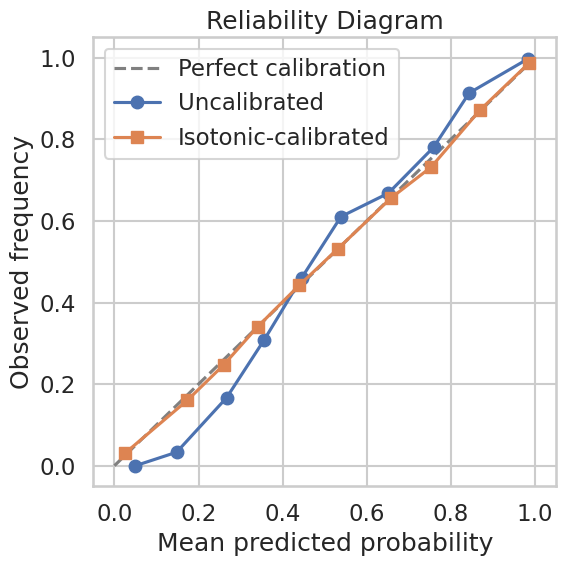

['/content/drive/MyDrive/My Work/Research/AI+ BBA/Supply Chain Disruption/DataCO/outputs_dataco/models/calibrated_model_RandomForest.joblib']

In [ ]:
frac_pos_raw, mean_pred_raw = calibration_curve(y_test, proba_test_raw, n_bins=10)
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, proba_test_cal, n_bins=10)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(mean_pred_raw, frac_pos_raw, marker="o", label="Uncalibrated")
ax.plot(mean_pred_cal, frac_pos_cal, marker="s", label="Isotonic-calibrated")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed frequency")
ax.set_title("Reliability Diagram")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/fig04_reliability_diagram.png", dpi=300)
plt.show()

joblib.dump(calibrated_model, f"{MODEL_DIR}/calibrated_model_{BEST_MODEL_NAME}.joblib")


## 9. Uncertainty Quantification

### 9a. Split Conformal Prediction

In [ ]:
from mapie.classification import MapieClassifier

ALPHA = 0.10
CONFIDENCE_LEVEL = 1 - ALPHA

# Replace SplitConformalClassifier with MapieClassifier for robustness
mapie_clf = MapieClassifier(
    estimator=best_pipeline,
    method="score", # Changed from "cumulated_score" to "score" for binary target
    cv="prefit",  # Crucial for split conformal prediction with a pre-fitted estimator
    random_state=RANDOM_STATE,
)
mapie_clf.fit(X_calib, y_calib) # Calibrate on the calibration set

y_pred, y_pred_set = mapie_clf.predict(X_test, alpha=ALPHA)
# For MapieClassifier, y_pred_set is (n_samples, n_classes, n_alpha).
# If alpha is a single value, it's (n_samples, n_classes, 1).
# We need to extract the boolean prediction sets, which is y_pred_set[:, :, 0]
pred_set_test = y_pred_set[:, :, 0]
y_test_array = np.asarray(y_test)

empirical_coverage = np.mean([pred_set_test[i, y_test_array[i]] for i in range(len(y_test_array))])
avg_set_size = pred_set_test.sum(axis=1).mean()

conformal_report = {
    "target_coverage": float(CONFIDENCE_LEVEL), "empirical_coverage": float(empirical_coverage),
    "coverage_gap": float(empirical_coverage - CONFIDENCE_LEVEL),
    "avg_prediction_set_size": float(avg_set_size),
}
print(json.dumps(conformal_report, indent=2))
with open(f"{METRIC_DIR}/conformal_report.json", "w") as f:
    json.dump(conformal_report, f, indent=2)


{
  "target_coverage": 0.9,
  "empirical_coverage": 0.9015898515399956,
  "coverage_gap": 0.0015898515399955793,
  "avg_prediction_set_size": 1.3600432085087526
}


In [ ]:
conformal_ambiguous = pred_set_test.sum(axis=1) > 1
print(f"Share of test shipments with an ambiguous (non-singleton) conformal set: {conformal_ambiguous.mean():.2%}")


Share of test shipments with an ambiguous (non-singleton) conformal set: 36.00%
